In [1]:
from pathlib import Path
import json

import numpy as np
from tritonclient.http import InferenceServerClient, InferInput, InferRequestedOutput

config input / output
```
max_batch_size: 256

input [
  {
    name: "image_bytes"
    data_type: TYPE_STRING
    dims: [ 1 ]
  }
]
output [
  {
    name: "layout_items"
    data_type: TYPE_STRING
    dims: [ 1 ]
  }
]
```

`max_batch_size` 가 설정되어 있어서 첫 축이 batch 축 - 페이지 1장당 1 row, shape `[num_pages, 1]`.

출력 row 는 `LayoutItem` (`tasks/pp-doclayout-v3/src/data.py`) 의 JSON list:

```python
{"label": str, "bbox": {"x1": int, "y1": int, "x2": int, "y2": int},
 "order": int, "score": float, "polygon_points": [{"x": int, "y": int}, ...]}
```

item 은 reading order (`order`) 기준으로 정렬되어 있음.

In [2]:
url = "localhost:8000"
model_name = "pp-doclayout-v3"

image_paths = [
    Path("data/example_page.jpeg"),
]

images = [p.read_bytes() for p in image_paths]

In [3]:
request_input = InferInput(
    "image_bytes",
    [len(images), 1],
    "BYTES"
)

input_data = np.array(images, dtype=object)[:, np.newaxis]
request_input.set_data_from_numpy(input_data, binary_data=True)
inputs = [request_input]
outputs = [InferRequestedOutput("layout_items", binary_data=True)]

In [4]:
with InferenceServerClient(url=url) as client:
    print("live:", client.is_server_live(), "| ready:", client.is_model_ready(model_name))
    results = client.infer(model_name=model_name, inputs=inputs, outputs=outputs)

live: True | ready: True


In [5]:
raw = results.as_numpy("layout_items").reshape(-1)
pages = [json.loads(x) for x in raw]

for path, items in zip(image_paths, pages):
    print(f"{path}: {len(items)} items")
    for item in items[:10]:
        bbox = item["bbox"]
        print(
            f"  order={item['order']:>3}  label={item['label']:<18}"
            f"  score={item['score']:.3f}"
            f"  bbox=({bbox['x1']},{bbox['y1']})-({bbox['x2']},{bbox['y2']})"
        )
    if len(items) > 10:
        print(f"  ... ({len(items) - 10} more)")

data/example_page.jpeg: 16 items
  order=  0  label=aside_text          score=0.899  bbox=(18,281)-(49,740)
  order= 28  label=header              score=0.753  bbox=(161,94)-(654,151)
  order= 45  label=doc_title           score=0.845  bbox=(279,196)-(534,221)
  order= 77  label=text                score=0.787  bbox=(153,311)-(290,356)
  order= 85  label=text                score=0.656  bbox=(304,311)-(413,356)
  order=102  label=text                score=0.628  bbox=(429,311)-(664,356)
  order=106  label=text                score=0.869  bbox=(166,378)-(283,424)
  order=130  label=text                score=0.849  bbox=(311,378)-(456,423)
  order=153  label=text                score=0.848  bbox=(483,378)-(649,423)
  order=158  label=text                score=0.852  bbox=(315,443)-(501,475)
  ... (6 more)


### 시각화

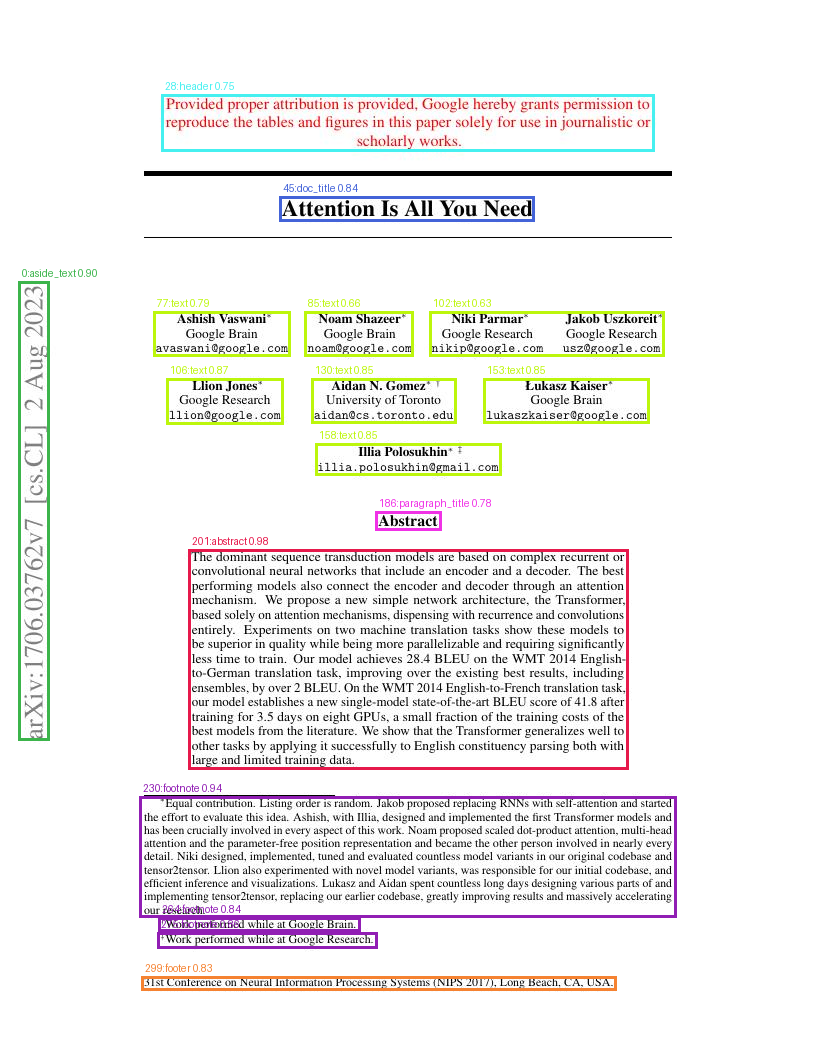

In [6]:
from PIL import Image, ImageDraw

PALETTE = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#008080", "#9a6324",
]


def draw_layout(image_path: Path, items: list[dict]) -> Image.Image:
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    labels = sorted({item["label"] for item in items})

    for item in items:
        color = PALETTE[labels.index(item["label"]) % len(PALETTE)]
        bbox = item["bbox"]
        draw.rectangle((bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]), outline=color, width=3)
        draw.text(
            (bbox["x1"] + 4, max(bbox["y1"] - 14, 0)),
            f"{item['order']}:{item['label']} {item['score']:.2f}",
            fill=color,
        )
    return image


draw_layout(image_paths[0], pages[0])

### 라벨 분포

In [7]:
from collections import Counter

counts = Counter(item["label"] for items in pages for item in items)
for label, count in counts.most_common():
    print(f"{label:<20} {count}")

text                 7
footnote             3
aside_text           1
header               1
doc_title            1
paragraph_title      1
abstract             1
footer               1
